# Project 2: Medical Route Optimization

This notebook demonstrates the Genetic Algorithm solution for the Vehicle Routing Problem (VRP) in a medical delivery context.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))

from src.models.location import Location
from src.models.vehicle import Vehicle
from src.algorithms.genetic_optimizer import GeneticOptimizer
from src.utils.plotter import Plotter
from src.llm.report_generator import ReportGenerator
from src.utils.data_loader import DataLoader

In [ ]:
# 1. Define Problem Data
depot = Location(0, 50, 50, "Central Depot")

# Select dataset: 'small', 'medium', or 'large'
DATASET = 'medium'

file_map = {
    'small': '../data/locations_small.json',
    'medium': '../data/locations_medium.json',
    'large': '../data/locations_large.json'
}

locations = DataLoader.load_locations(file_map[DATASET])

# Create Fleet
# Estimate required capacity
deliveries = [l for l in locations if getattr(l, 'type', 'delivery') == 'delivery']
total_demand = sum(l.demand for l in deliveries)
veh_capacity = 4
# num_vehicles = (total_demand // veh_capacity) + 2 # Add spare
num_vehicles = 2

fleet = []
for i in range(num_vehicles):
    fleet.append(Vehicle(id=i+1, capacity=veh_capacity, max_distance=100.0))

print(f"Loaded {len(locations)} locations (including gas stations) from {DATASET} dataset.")
print(f"Created Fleet of {len(fleet)} vehicles with capacity {veh_capacity} and range {100.0}")

Loaded 24 locations (including gas stations) from medium dataset.
Created Fleet of 5 vehicles with capacity 4 and range 100.0


In [7]:
# 2. Run Genetic Algorithm
# Adjust generations/pop_size based on problem size if needed
generations = 200 if DATASET == 'large' else 150
pop_size = 100 if DATASET == 'large' else 60

optimizer = GeneticOptimizer(locations, depot, fleet, generations=generations, pop_size=pop_size)
best_routes, best_dist = optimizer.run()

print(f"Best Total Distance: {best_dist:.2f}")
print(f"Total Vehicles Used: {len(best_routes)}")

Best Total Distance: 698.33
Total Vehicles Used: 5


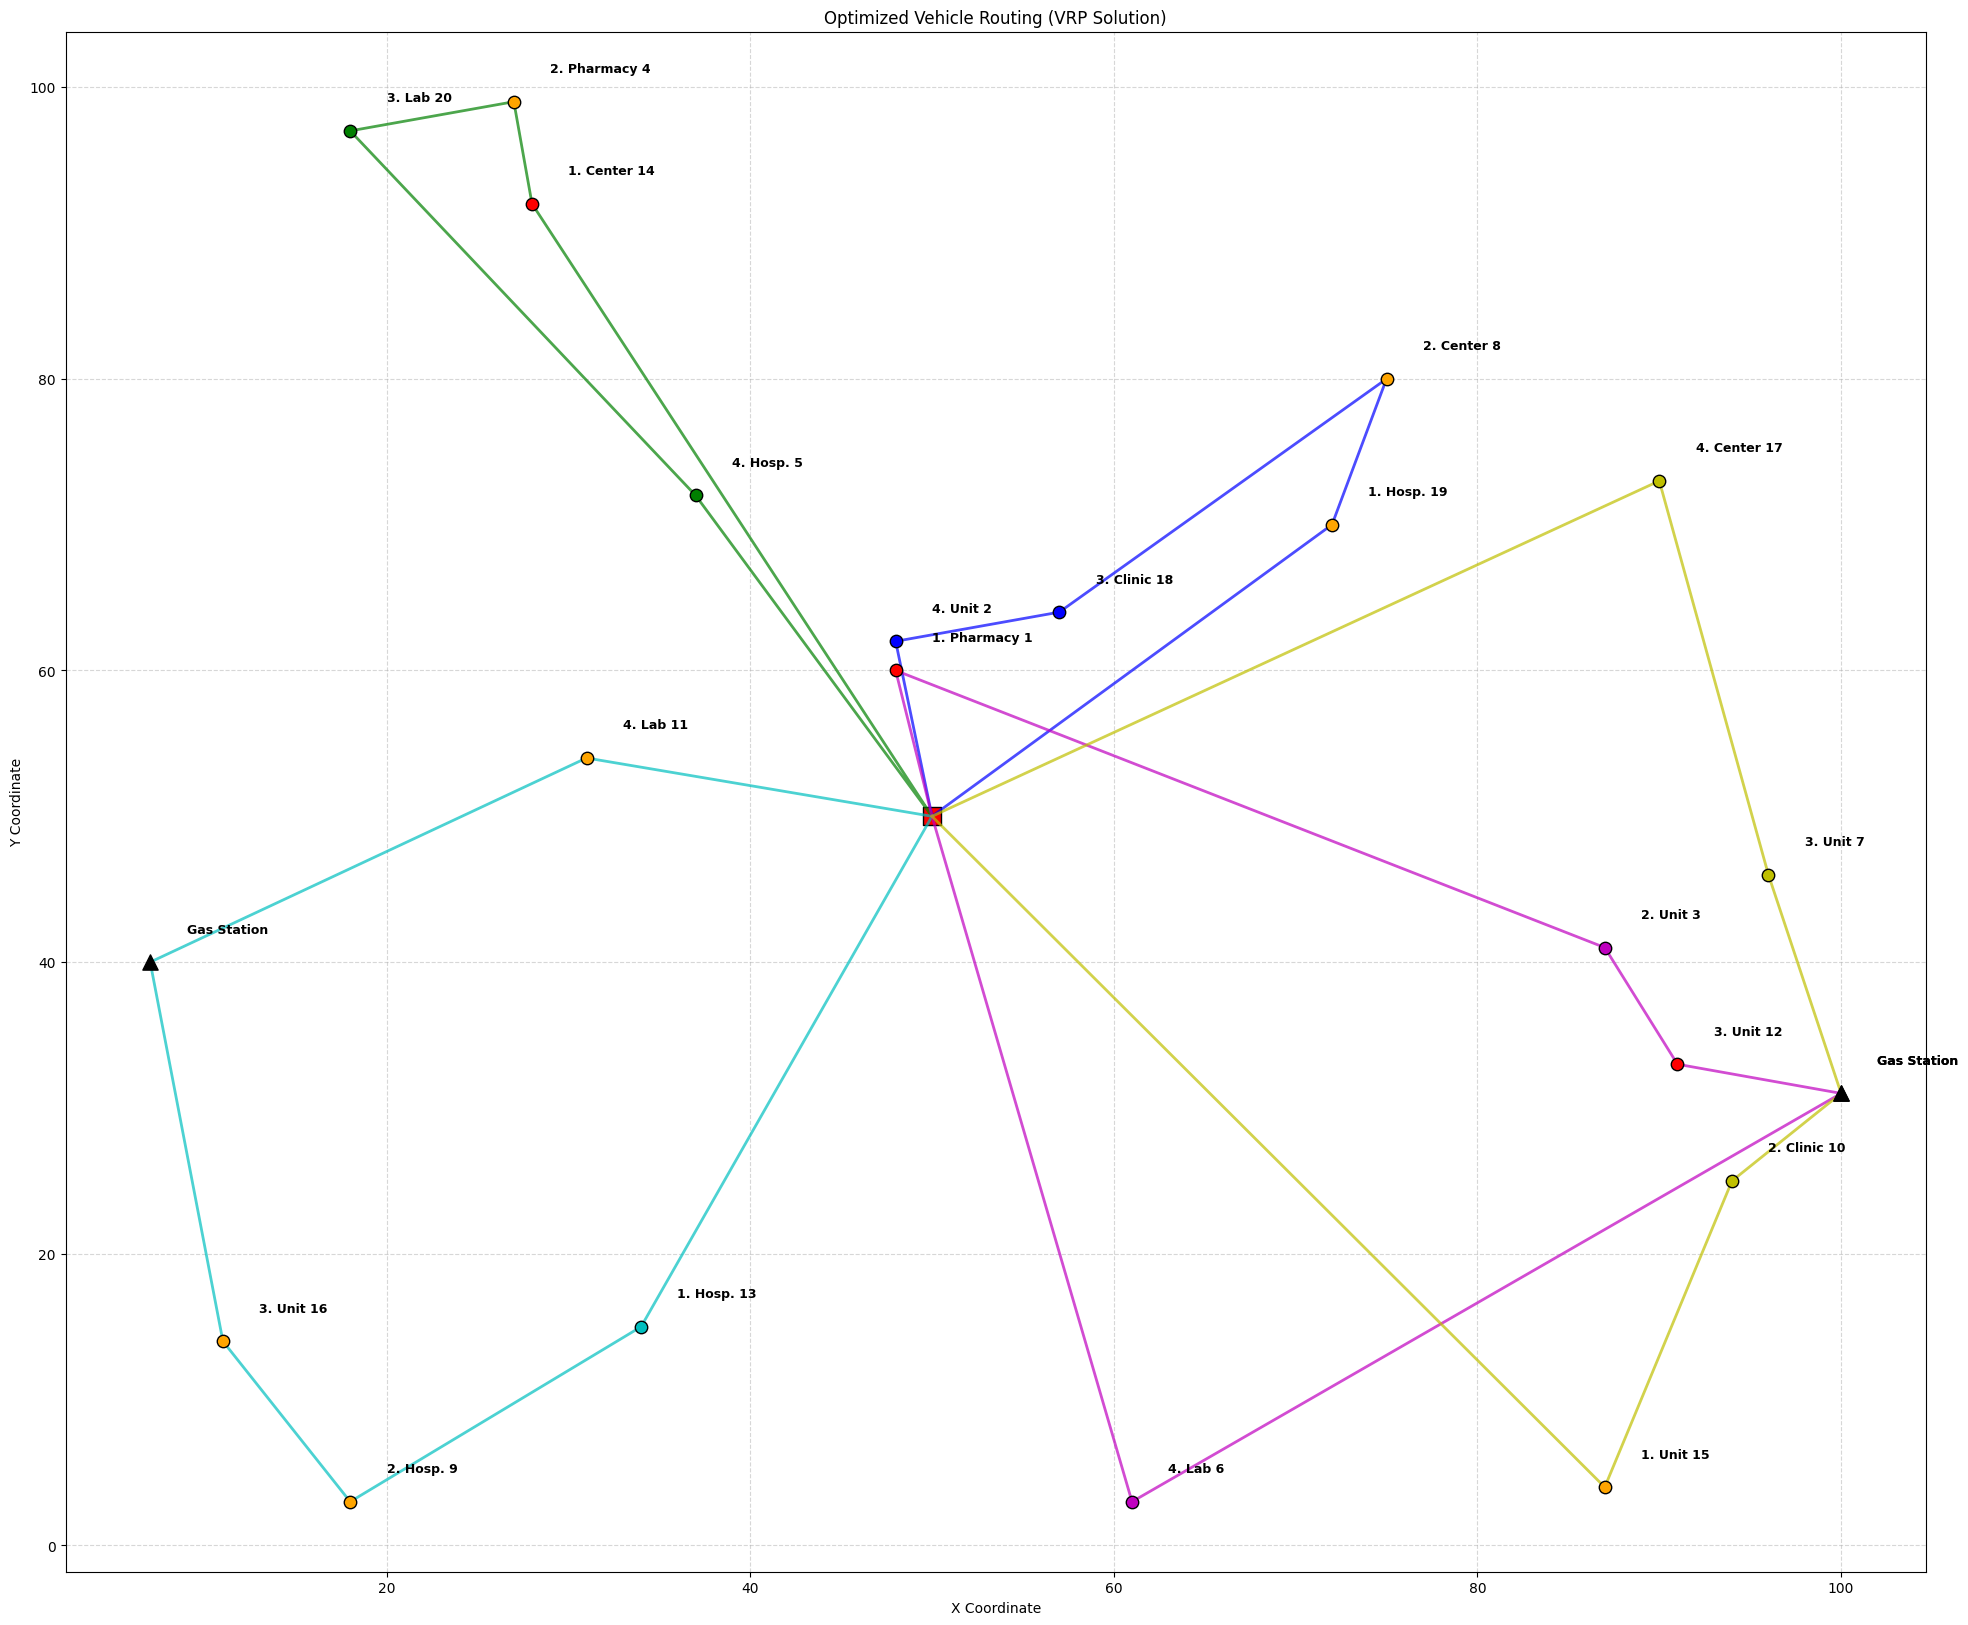

In [8]:
# 3. Visualize Solution
Plotter.plot_solution(best_routes, depot)

In [5]:
# 4. Generate LLM Report
llm = ReportGenerator() # Will use mock if no API key

print("Generating Instructions for Drivers...\n")

# Limit output for large datasets to avoid spamming the notebook
max_reports = 3 if DATASET == 'large' else 100

for i, route in enumerate(best_routes[:max_reports]):
    print(llm.generate_driver_instructions(i, route))
    print("\n" + "="*40 + "\n")

if len(best_routes) > max_reports:
    print(f"... and {len(best_routes) - max_reports} more routes.")

Generating Instructions for Drivers...

*** ROUTE PLAN (SIMULATED LLM OUTPUT) FOR DRIVER 1 ***
Good morning! Here is your optimized delivery route for today.

1. 🏭 DEPART from Central Depot.
2. 🏥 DELIVER to Center 14. Priority: CRITICAL 🔴
3. 🏥 DELIVER to Pharmacy 4. Priority: HIGH kz
4. 🏥 DELIVER to Lab 20. Priority: Normal 🟢
5. 🏥 DELIVER to Hosp. 5. Priority: Normal 🟢
6. 🏁 RETURN to Central Depot.

Drive safely!


*** ROUTE PLAN (SIMULATED LLM OUTPUT) FOR DRIVER 2 ***
Good morning! Here is your optimized delivery route for today.

1. 🏭 DEPART from Central Depot.
2. 🏥 DELIVER to Pharmacy 1. Priority: CRITICAL 🔴
3. 🏥 DELIVER to Unit 2. Priority: Normal 🟢
4. 🏥 DELIVER to Unit 7. Priority: Normal 🟢
5. 🏥 DELIVER to Unit 3. Priority: Normal 🟢
6. 🏁 RETURN to Central Depot.

Drive safely!


*** ROUTE PLAN (SIMULATED LLM OUTPUT) FOR DRIVER 3 ***
Good morning! Here is your optimized delivery route for today.

1. 🏭 DEPART from Central Depot.
2. 🏥 DELIVER to Lab 6. Priority: Normal 🟢
3. 🏥 DELIVER